# Conformal Prediction Position Sizing: Two Case Studies

**Docker image**: `ml4t`

This notebook builds uncertainty-based position sizing on top of registered
walk-forward GBM predictions for two case studies — 100 ETFs (8 folds,
`fwd_ret_21d`) and 30 CME futures products (5 folds, `fwd_ret_5d`) — and
compares three allocation rules at the same top-K selection: equal weight,
conformal-width-weighted ($w_i \propto 1/\Delta_i$), and score-weighted
($w_i \propto |\hat y_i|$).

**Learning Objectives**:
- Compute per-symbol Mondrian split-conformal interval widths from
  out-of-fold residuals
- Translate widths into position sizes via the inverse-width transform
- Compare uncertainty-weighted, score-weighted, and equal-weighted top-K
  allocations on the same prediction panel
- Identify when uncertainty-based sizing helps versus hurts

**Book Reference**: Chapter 17, Section 17.4 (Defining Baseline Allocators)

**Prerequisites**: `02_mean_variance_optimization`; conformal prediction from
Chapter 11 (`06_conformal_prediction`); registered GBM predictions for the
ETFs and CME futures case studies.

In [1]:
"""Conformal Prediction Position Sizing — Mondrian split conformal applied to registered GBM predictions for ETFs and CME futures, with three allocation rules at the same top-K selection."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from ml4t.diagnostic.signal.signal_ic import compute_ic_summary, extract_signal_ic_series

from case_studies.utils.analytics import resolve_best_prediction
from utils.paths import get_case_study_dir

warnings.filterwarnings("ignore")

In [2]:
# Production defaults — Papermill overrides for CI testing
CONFORMAL_ALPHA = 0.20  # 80% prediction interval
TOP_K_ETF = 20  # number of ETFs in the portfolio
TOP_K_CME = 10  # number of CME products in the portfolio
HORIZON_ETF = 21  # fwd_ret_21d → 21 trading days between non-overlapping rebalances
HORIZON_CME = 5  # fwd_ret_5d  → 5 trading days
TRADING_DAYS_PER_YEAR = 252

## 1. The Conformal-to-Confidence Transform

Conformal prediction produces calibrated prediction intervals
$[\hat{y}_i - q, \hat{y}_i + q]$ where the width $2q$ reflects model uncertainty.
The key insight for portfolio construction: **narrower intervals indicate higher
model confidence for that asset at that time**.

The confidence-weighted position for asset $i$ at time $t$ within a top-$K$
selection is:

$$w_{i,t}^{conf} = \frac{1 / \Delta_{i,t}}{\sum_{j \in \text{top-}K} 1 / \Delta_{j,t}}$$

where $\Delta_{i,t}$ is the per-asset interval width. To produce per-asset
variation in $\Delta_i$, we use **Mondrian split-conformal calibration**:
for each fold $k$, the conformal quantile $q_i$ is computed *separately for each
symbol $i$* from that symbol's out-of-fold residuals. Symbols whose residuals are
historically wider get larger $\Delta_i$ and therefore smaller weight.

## 2. Load Registered Predictions

We load the best-IC GBM walk-forward prediction set for each case study from
the per-case-study run-log registry.

In [3]:
REGISTRY_ROOTS = {
    "etfs": get_case_study_dir("etfs") / "run_log",
    "cme_futures": get_case_study_dir("cme_futures") / "run_log",
}

# Per-case-study label + identifier. The best-IC GBM `prediction_hash` is
# resolved at runtime from each registry's `prediction_metrics`, so re-running
# the GBM sweep for either case study automatically updates which predictions
# feed the conformal pipeline below.
BEST_GBM = {
    "etfs": {"label": "fwd_ret_21d", "id_col": "symbol"},
    "cme_futures": {"label": "fwd_ret_5d", "id_col": "product"},
}

for _cs, _cfg in BEST_GBM.items():
    _best = resolve_best_prediction(_cs, _cfg["label"], family="gbm")
    _cfg["prediction_hash"] = _best["prediction_hash"]
    print(
        f"Resolved best-IC GBM for {_cs}: hash={_cfg['prediction_hash']}, "
        f"config={_best['config_name']}, ic_mean={_best['ic_mean']:.4f}"
    )

Resolved best-IC GBM for etfs: hash=e716461a3d25, config=leaves_7_mse, ic_mean=0.0371
Resolved best-IC GBM for cme_futures: hash=30f32c88a3f8, config=leaves_15_mae, ic_mean=0.0322


In [4]:
def load_predictions(case_study: str) -> pl.DataFrame:
    """Load the best-IC GBM prediction parquet for one case study.

    Returns columns: timestamp, <id_col>, fold, prediction, actual.
    """
    cfg = BEST_GBM[case_study]
    path = (
        REGISTRY_ROOTS[case_study] / "predictions" / cfg["prediction_hash"] / "predictions.parquet"
    )
    df = pl.read_parquet(path)
    # Standardize identifier column to "asset" so downstream code is shared.
    return df.rename({cfg["id_col"]: "asset"}).select(
        "timestamp", "asset", "fold", "prediction", "actual"
    )

In [5]:
preds = {cs: load_predictions(cs) for cs in REGISTRY_ROOTS}
for cs, df in preds.items():
    cfg = BEST_GBM[cs]
    print(
        f"{cs:>14}  rows={df.height:>7,}  assets={df['asset'].n_unique():>3}  "
        f"folds={df['fold'].n_unique()}  label={cfg['label']}  "
        f"window={df['timestamp'].min()} → {df['timestamp'].max()}"
    )

          etfs  rows=190,234  assets= 99  folds=8  label=fwd_ret_21d  window=2015-12-28 00:00:00 → 2023-12-29 00:00:00
   cme_futures  rows= 38,394  assets= 30  folds=5  label=fwd_ret_5d  window=2019-01-04 00:00:00 → 2023-12-29 00:00:00


## 3. Signal Strength of the Underlying GBM Predictions

Conformal position sizing only adds value when the underlying signal has
meaningful cross-sectional predictive power. If IC is near zero, weighting
*anything* by inverse uncertainty cannot rescue the strategy — the
conformal widths just rescale noise.

We use `ml4t.diagnostic.signal.extract_signal_ic_series` and
`compute_ic_summary` to summarize the daily cross-sectional Spearman IC of
each case study's GBM prediction set against its label horizon. The two
case studies clear the IC bar by similar margins; the next step is to check
**per-asset width dispersion** in §4, which Mondrian calibration exposes —
one input to whether inverse-width sizing helps, though, as §8 shows, not on
its own decisive (CME has the wider width ratio yet the worse conformal-vs-EW
Sharpe).

In [6]:
ic_summaries = {}
for cs, df in preds.items():
    horizon = HORIZON_ETF if cs == "etfs" else HORIZON_CME
    sig_df = df.rename(
        {
            "timestamp": "date",
            "prediction": "factor",
            "actual": f"{horizon}D_fwd_return",
        }
    ).select(["date", "asset", "factor", f"{horizon}D_fwd_return"])
    _, ic_values = extract_signal_ic_series(sig_df, period=horizon)
    ic_summaries[cs] = {
        **compute_ic_summary(ic_values),
        "horizon": horizon,
        "n_dates": len(ic_values),
    }

print(
    f"{'Case study':>14}  {'horizon':>7}  {'mean IC':>8}  {'IC std':>7}  {'t-stat':>7}  {'p-value':>8}  {'% pos':>6}  n_dates"
)
print("-" * 80)
for cs, s in ic_summaries.items():
    print(
        f"{cs:>14}  {s['horizon']:>7}d  "
        f"{s['mean']:>+8.4f}  {s['std']:>7.4f}  {s['t_stat']:>+7.2f}  "
        f"{s['p_value']:>8.2e}  {s['pct_positive'] * 100:>5.1f}%  {s['n_dates']}"
    )

    Case study  horizon   mean IC   IC std   t-stat   p-value   % pos  n_dates
--------------------------------------------------------------------------------
          etfs       21d   +0.0371   0.2734    +6.10  1.30e-09   54.7%  2016
   cme_futures        5d   +0.0322   0.2732    +4.23  2.49e-05   54.2%  1290


Read the table as a **necessary precondition**. Both case studies clear
the bar: t-stats above 4, mean IC ≈ 0.03, and >54% of dates with a
positive cross-sectional rank correlation between prediction and realized
return. So neither case study is a pure-noise signal where conformal
sizing would be perturbing zero.

Necessary, not sufficient. Whether conformal sizing actually helps over
equal weight depends on the **dispersion of conformal widths** the
Mondrian calibration produces — the topic of §4. A case study with strong
IC but flat per-asset widths reduces to equal weight regardless of signal
strength.

## 4. Per-Symbol Mondrian Conformal Width (Walk-Forward)

For each fold $k$ and each symbol $i$, we compute the conformal quantile from
the absolute residuals on **chronologically prior folds**. The width applied
to fold-$k$ predictions for symbol $i$ is

$$\Delta_{i,k} = 2 \cdot \hat q_{1-\alpha}\bigl(\{|y_{i,t} - \hat y_{i,t}| : \text{fold}(t) \prec k\}\bigr).$$

This mirrors the production conformal protocol
(`case_studies/utils/conformal.py::compute_conformal_widths`): per-symbol
Mondrian quantiles on a strictly walk-forward calibration pool, so no future
residuals leak into earlier fold widths. The chronologically earliest fold
has no prior, so its calibration falls back to "all OTHER folds" (the
cross-conformal earliest-fold pattern) — this row is forward-looking by
construction and should be read as a diagnostic, not as a walk-forward
sizing test for that one fold.

Per-symbol calibration produces width *variation across assets*, which is
the variation that drives the $1/\Delta_i$ weighting. Pooled (cross-symbol)
split conformal would produce a single width per fold, collapsing the
conformal weights to equal weights.

In [7]:
def mondrian_widths(df: pl.DataFrame, alpha: float) -> pl.DataFrame:
    """Return one (asset, fold, width) row per (asset, fold) pair.

    Width = 2 × the (1-α)-quantile of |residual| on chronologically prior
    folds, computed per asset. The earliest fold falls back to all OTHER
    folds (cross-conformal) since it has no walk-forward prior — mirrors
    the production library's earliest-fold handling.
    """
    df = df.with_columns(abs_resid=(pl.col("actual") - pl.col("prediction")).abs())

    # Order folds chronologically by their earliest timestamp. Fold IDs are
    # not reliably chronological across CV schemes, so we derive order from
    # data — same as case_studies.utils.conformal.
    fold_ts = df.group_by("fold").agg(ts_min=pl.col("timestamp").min()).sort("ts_min")
    fold_chronological: list[int] = fold_ts["fold"].to_list()
    prior_folds_for: dict[int, list[int]] = {}
    for i, f in enumerate(fold_chronological):
        prior_folds_for[f] = (
            fold_chronological[:i] if i > 0 else [g for g in fold_chronological if g != f]
        )

    rows = []
    for k in fold_chronological:
        prior = prior_folds_for[k]
        cal = df.filter(pl.col("fold").is_in(prior))
        if cal.is_empty():
            continue
        widths_k = (
            cal.group_by("asset")
            .agg(q=pl.col("abs_resid").quantile(1.0 - alpha, interpolation="higher"))
            .with_columns(fold=pl.lit(k, dtype=pl.Int64), width=2.0 * pl.col("q"))
            .select("asset", "fold", "width")
        )
        rows.append(widths_k)
    return pl.concat(rows)

In [8]:
widths = {cs: mondrian_widths(preds[cs], CONFORMAL_ALPHA) for cs in preds}

print(f"=== Per-symbol conformal widths (α={CONFORMAL_ALPHA}) ===\n")
for cs, w in widths.items():
    stats = w["width"].describe()
    n_zero = (w["width"] == 0).sum()
    print(f"{cs:>14}  rows={w.height:>4}  zero-width={n_zero:>2}")
    print(w.describe())
    print()

=== Per-symbol conformal widths (α=0.2) ===

          etfs  rows= 775  zero-width= 0
shape: (9, 4)
┌────────────┬───────┬──────────┬──────────┐
│ statistic  ┆ asset ┆ fold     ┆ width    │
│ ---        ┆ ---   ┆ ---      ┆ ---      │
│ str        ┆ str   ┆ f64      ┆ f64      │
╞════════════╪═══════╪══════════╪══════════╡
│ count      ┆ 775   ┆ 775.0    ┆ 775.0    │
│ null_count ┆ 0     ┆ 0.0      ┆ 0.0      │
│ mean       ┆ null  ┆ 3.467097 ┆ 0.121325 │
│ std        ┆ null  ┆ 2.299003 ┆ 0.059566 │
│ min        ┆ ACWI  ┆ 0.0      ┆ 0.023564 │
│ 25%        ┆ null  ┆ 1.0      ┆ 0.093696 │
│ 50%        ┆ null  ┆ 3.0      ┆ 0.112096 │
│ 75%        ┆ null  ┆ 5.0      ┆ 0.142948 │
│ max        ┆ XRT   ┆ 7.0      ┆ 0.406493 │
└────────────┴───────┴──────────┴──────────┘

   cme_futures  rows= 150  zero-width= 0
shape: (9, 4)
┌────────────┬───────┬──────────┬──────────┐
│ statistic  ┆ asset ┆ fold     ┆ width    │
│ ---        ┆ ---   ┆ ---      ┆ ---      │
│ str        ┆ str   ┆ f64      ┆ 

Width statistics let us see how much per-asset dispersion the calibration produces.
If symbol-level residual distributions are similar (homogeneous universe), widths
concentrate near the median and inverse-width weights collapse toward equal
weight. If they are heterogeneous, widths spread out and conformal weighting
diverges from EW.

## 5. Allocation Rules

At each timestamp $t$ we (a) select the top-$K$ assets by **signed**
$\hat y_{i,t}$, restricted to rows whose prediction is positive (long-only
return-score allocation), then (b) form weights using each rule:

- **Equal weight**: $w_i = 1/K$.
- **Conformal-weighted**: $w_i = (1/\Delta_{i,t}) / \sum_{j \in \text{top-}K}(1/\Delta_{j,t})$.
- **Score-weighted**: $w_i = \hat y_{i,t} / \sum_{j \in \text{top-}K}\hat y_{j,t}$.

All weights are non-negative and sum to one — long-only by construction. The
realized portfolio return at $t$ is $r_t = \sum_i w_{i,t}\,y_{i,t}$, where
$y_{i,t}$ is the realized forward return label aligned to the prediction
timestamp (`actual` column in the parquet). If fewer than $K$ assets have
a positive predicted return at $t$, the selection drops to that smaller
size; if none are positive the timestamp is skipped.

In [9]:
def build_portfolio_returns(
    df: pl.DataFrame, widths: pl.DataFrame, top_k: int, horizon: int
) -> pl.DataFrame:
    """Per-timestamp top-K portfolio returns under three allocation rules.

    Uses non-overlapping rebalances: within each fold, only every ``horizon``-th
    unique timestamp is kept, so realized forward-`horizon`-day returns do not
    overlap. The realized portfolio return at a kept timestamp t is
    Σ_i w_{i,t} · actual_{i,t}.

    Returns (realized, weights_long).
    """
    df = df.join(widths, on=["asset", "fold"], how="left").drop_nulls(
        subset=["prediction", "actual", "width"]
    )

    # Within each fold, retain only every horizon-th unique timestamp (sorted ascending).
    fold_ts = (
        df.select("fold", "timestamp")
        .unique()
        .sort(["fold", "timestamp"])
        .with_columns(
            ts_rank=pl.col("timestamp").rank(method="ordinal").over("fold").cast(pl.Int64)
        )
        .filter((pl.col("ts_rank") - 1) % horizon == 0)
        .select("fold", "timestamp")
    )
    df = df.join(fold_ts, on=["fold", "timestamp"], how="inner")

    # Long-only return-score allocation: restrict to assets with a positive
    # predicted return, then rank by signed prediction. A top-K selection by
    # |prediction| would allocate long capital to strongly negative
    # forecasts; ranking by signed prediction keeps the rule coherent with
    # the long-only weight form below.
    df = df.filter(pl.col("prediction") > 0).with_columns(
        rank=pl.col("prediction").rank(method="ordinal", descending=True).over("timestamp")
    )
    top = df.filter(pl.col("rank") <= top_k)

    inv_w = 1.0 / pl.col("width")
    score = pl.col("prediction")

    top = top.with_columns(
        w_ew=pl.lit(1.0) / pl.len().over("timestamp"),
        w_conf=inv_w / inv_w.sum().over("timestamp"),
        w_score=score / score.sum().over("timestamp"),
    )

    realized = (
        top.group_by("timestamp")
        .agg(
            ret_ew=(pl.col("w_ew") * pl.col("actual")).sum(),
            ret_conf=(pl.col("w_conf") * pl.col("actual")).sum(),
            ret_score=(pl.col("w_score") * pl.col("actual")).sum(),
        )
        .sort("timestamp")
    )
    weights_long = top.select("timestamp", "asset", "w_ew", "w_conf", "w_score").sort(
        "timestamp", "asset"
    )
    return realized, weights_long

In [10]:
def compute_turnover(weights_long: pl.DataFrame, weight_col: str) -> float:
    """Mean per-timestamp Σ_i |w_{i,t} - w_{i,t-1}|."""
    w = weights_long.pivot(
        index="timestamp", on="asset", values=weight_col, aggregate_function="first"
    ).fill_null(0.0)
    arr = w.drop("timestamp").to_numpy()
    if arr.shape[0] < 2:
        return float("nan")
    return float(np.mean(np.abs(np.diff(arr, axis=0)).sum(axis=1)))


def metric_block(
    rets: pl.DataFrame, weights: pl.DataFrame, horizon: int
) -> dict[str, dict[str, float]]:
    """Sharpe / Sortino / MaxDD / WinRate / Turnover for the three allocators."""
    # Annualization: each observation is one horizon-period forward return.
    periods_per_year = TRADING_DAYS_PER_YEAR / horizon
    ann_sqrt = np.sqrt(periods_per_year)

    out = {}
    for name, ret_col, w_col in [
        ("baseline_equal_weight", "ret_ew", "w_ew"),
        ("conformal_weighted", "ret_conf", "w_conf"),
        ("score_weighted", "ret_score", "w_score"),
    ]:
        r = rets[ret_col].to_numpy()
        mu = r.mean()
        sd = r.std(ddof=1)
        _downside_raw = float(np.sqrt(np.mean(np.minimum(r, 0.0) ** 2)))
        downside = _downside_raw if _downside_raw > 0 else np.nan
        cum = np.cumprod(1.0 + r)
        peak = np.maximum.accumulate(cum)
        max_dd = float((cum / peak - 1.0).min())
        out[name] = {
            "sharpe": float(mu / sd * ann_sqrt) if sd > 0 else float("nan"),
            "sortino": float(mu / downside * ann_sqrt)
            if downside == downside and downside > 0
            else float("nan"),
            "max_drawdown": max_dd,
            "win_rate": float((r > 0).mean()),
            "avg_turnover": compute_turnover(weights, w_col),
            "n_obs": int(r.shape[0]),
            "ann_return": float((1 + mu) ** periods_per_year - 1) if mu > -1 else float("nan"),
        }
    return out

**On rebalancing and annualization.** The prediction panel is daily but each
row's `actual` is a forward 5-day or 21-day return. To avoid the overlap that
would inflate Sharpe and break drawdown accounting, we rebalance every
`HORIZON` trading days and use only those non-overlapping observations. The
Sharpe is annualized by $\sqrt{252/h}$ — for ETFs with $h=21$ this is
$\sqrt{12}$; for CME with $h=5$ this is $\sqrt{50.4}$. The realized portfolio
return at each rebalance date $t$ is $\sum_i w_{i,t}\,y_{i,t}$, where $y_{i,t}$
is the $h$-day forward return and the cohort is held to maturity (no
intra-period rebalancing).

## 6. ETFs (100 assets, 8 folds, fwd_ret_21d)

The headline Sharpe below pools all folds, so one of eight folds is sized
with the earliest-fold cross-conformal (not walk-forward) widths flagged in
§4 — a small forward-looking component in an otherwise walk-forward result.

In [11]:
etf_rets, etf_weights = build_portfolio_returns(
    preds["etfs"], widths["etfs"], TOP_K_ETF, HORIZON_ETF
)
etf_metrics = metric_block(etf_rets, etf_weights, HORIZON_ETF)
print(f"ETFs non-overlapping rebalances: {etf_rets.height}")

ETFs non-overlapping rebalances: 77


In [12]:
print("=== ETFs: Allocation Method Comparison ===\n")
print(
    f"{'Method':<22} {'Sharpe':>8} {'Sortino':>8} {'Max DD':>8} {'Win Rate':>10} {'Turnover':>10}"
)
print("-" * 70)
for label, key in [
    ("Equal Weight", "baseline_equal_weight"),
    ("Conformal Weighted", "conformal_weighted"),
    ("Score Weighted", "score_weighted"),
]:
    m = etf_metrics[key]
    print(
        f"{label:<22} {m['sharpe']:>8.3f} {m['sortino']:>8.3f} "
        f"{m['max_drawdown']:>8.1%} {m['win_rate']:>10.1%} {m['avg_turnover']:>10.3f}"
    )

ew_s = etf_metrics["baseline_equal_weight"]["sharpe"]
cf_s = etf_metrics["conformal_weighted"]["sharpe"]
print(f"\nConformal vs EW Sharpe change: {cf_s - ew_s:+.4f} ({(cf_s - ew_s) / ew_s:+.1%})")

=== ETFs: Allocation Method Comparison ===

Method                   Sharpe  Sortino   Max DD   Win Rate   Turnover
----------------------------------------------------------------------
Equal Weight              0.589    0.904   -36.1%      57.1%      1.065
Conformal Weighted        0.534    0.825   -34.8%      58.4%      1.179
Score Weighted            0.651    1.023   -36.4%      55.8%      1.100

Conformal vs EW Sharpe change: -0.0548 (-9.3%)


### ETF Width Statistics

In [13]:
etf_iw = widths["etfs"]["width"]
print(f"""ETF Mondrian Conformal Width Statistics:
  N (asset × fold) :  {etf_iw.len()}
  Mean width       :  {etf_iw.mean():.4f}
  Median width     :  {etf_iw.median():.4f}
  Std width        :  {etf_iw.std():.4f}
  Min width        :  {etf_iw.min():.4f}
  Max width        :  {etf_iw.max():.4f}
  Width range      :  {etf_iw.max() / max(etf_iw.min(), 1e-12):.1f}x
  Alpha            :  {CONFORMAL_ALPHA}
""")

ETF Mondrian Conformal Width Statistics:
  N (asset × fold) :  775
  Mean width       :  0.1213
  Median width     :  0.1121
  Std width        :  0.0596
  Min width        :  0.0236
  Max width        :  0.4065
  Width range      :  17.3x
  Alpha            :  0.2



## 7. CME Futures (30 products, 5 folds, fwd_ret_5d)

As in §6, the headline Sharpe pools all folds, so one of five is sized with
the earliest-fold cross-conformal (not walk-forward) widths (§4 caveat).

In [14]:
cme_rets, cme_weights = build_portfolio_returns(
    preds["cme_futures"], widths["cme_futures"], TOP_K_CME, HORIZON_CME
)
cme_metrics = metric_block(cme_rets, cme_weights, HORIZON_CME)
print(f"CME non-overlapping rebalances: {cme_rets.height}")

CME non-overlapping rebalances: 260


In [15]:
print("=== CME Futures: Allocation Method Comparison ===\n")
print(
    f"{'Method':<22} {'Sharpe':>8} {'Sortino':>8} {'Max DD':>8} {'Win Rate':>10} {'Turnover':>10}"
)
print("-" * 70)
for label, key in [
    ("Equal Weight", "baseline_equal_weight"),
    ("Conformal Weighted", "conformal_weighted"),
    ("Score Weighted", "score_weighted"),
]:
    m = cme_metrics[key]
    print(
        f"{label:<22} {m['sharpe']:>8.3f} {m['sortino']:>8.3f} "
        f"{m['max_drawdown']:>8.1%} {m['win_rate']:>10.1%} {m['avg_turnover']:>10.3f}"
    )

ew_s = cme_metrics["baseline_equal_weight"]["sharpe"]
cf_s = cme_metrics["conformal_weighted"]["sharpe"]
print(f"\nConformal vs EW Sharpe change: {cf_s - ew_s:+.4f} ({(cf_s - ew_s) / ew_s:+.1%})")

=== CME Futures: Allocation Method Comparison ===

Method                   Sharpe  Sortino   Max DD   Win Rate   Turnover
----------------------------------------------------------------------
Equal Weight              0.740    1.117   -29.8%      56.2%      0.612
Conformal Weighted        0.633    0.924   -26.5%      55.8%      0.796
Score Weighted            0.613    0.925   -30.5%      56.5%      0.706

Conformal vs EW Sharpe change: -0.1070 (-14.5%)


### CME Width Statistics

In [16]:
cme_iw = widths["cme_futures"]["width"]
print(f"""CME Futures Mondrian Conformal Width Statistics:
  N (asset × fold) :  {cme_iw.len()}
  Mean width       :  {cme_iw.mean():.4f}
  Median width     :  {cme_iw.median():.4f}
  Std width        :  {cme_iw.std():.4f}
  Min width        :  {cme_iw.min():.4f}
  Max width        :  {cme_iw.max():.4f}
  Width range      :  {cme_iw.max() / max(cme_iw.min(), 1e-12):.1f}x
  Alpha            :  {CONFORMAL_ALPHA}
""")

CME Futures Mondrian Conformal Width Statistics:
  N (asset × fold) :  150
  Mean width       :  0.0647
  Median width     :  0.0596
  Std width        :  0.0421
  Min width        :  0.0040
  Max width        :  0.2306
  Width range      :  57.6x
  Alpha            :  0.2



## 8. Side-by-Side Sharpe Comparison

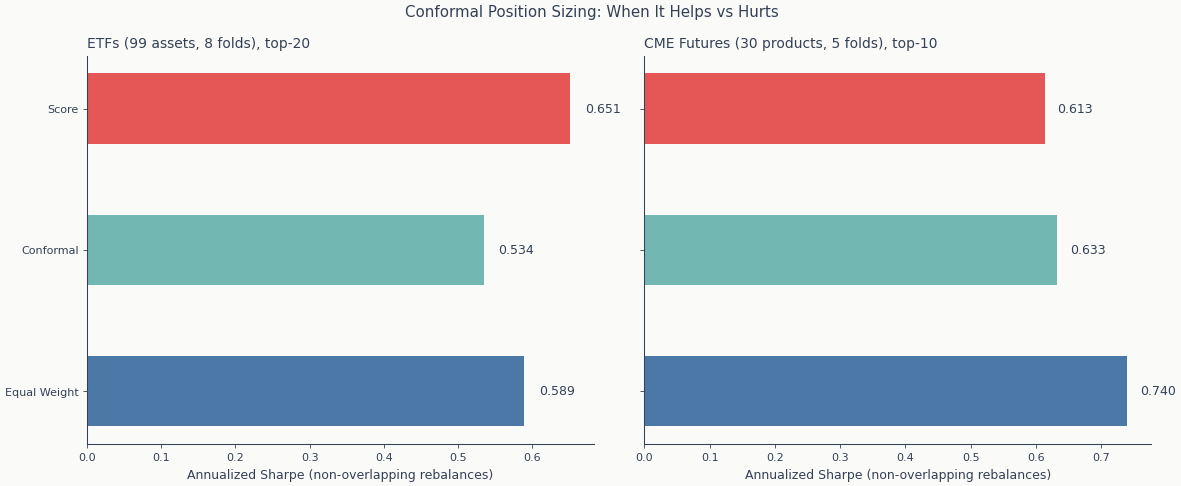

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, name, mblock, top_k, n_folds in [
    (
        axes[0],
        f"ETFs ({preds['etfs']['asset'].n_unique()} assets, {preds['etfs']['fold'].n_unique()} folds)",
        etf_metrics,
        TOP_K_ETF,
        preds["etfs"]["fold"].n_unique(),
    ),
    (
        axes[1],
        f"CME Futures ({preds['cme_futures']['asset'].n_unique()} products, {preds['cme_futures']['fold'].n_unique()} folds)",
        cme_metrics,
        TOP_K_CME,
        preds["cme_futures"]["fold"].n_unique(),
    ),
]:
    methods = ["Equal Weight", "Conformal", "Score"]
    sharpes = [
        mblock["baseline_equal_weight"]["sharpe"],
        mblock["conformal_weighted"]["sharpe"],
        mblock["score_weighted"]["sharpe"],
    ]
    colors = ["#4C78A8", "#72B7B2", "#E45756"]
    ax.barh(methods, sharpes, color=colors, height=0.5)
    ax.set_xlabel("Annualized Sharpe (non-overlapping rebalances)")
    ax.set_title(f"{name}, top-{top_k}")
    ax.axvline(x=0, color="gray", linestyle="--", alpha=0.3)
    for i, v in enumerate(sharpes):
        ax.text(
            v + (0.02 if v >= 0 else -0.02),
            i,
            f"{v:.3f}",
            va="center",
            ha="left" if v >= 0 else "right",
            fontsize=9,
        )

fig.suptitle("Conformal Position Sizing: When It Helps vs Hurts")
fig.tight_layout()
fig.show()

## 9. Cross-Case-Study Summary

In [18]:
print("=== Conformal Sizing: Cross-Case-Study Summary ===\n")
print(f"{'Metric':<28} {'ETFs':>12} {'CME Futures':>12}")
print("-" * 56)

rows: list[tuple[str, float | int, float | int]] = [
    (
        "EW Sharpe",
        etf_metrics["baseline_equal_weight"]["sharpe"],
        cme_metrics["baseline_equal_weight"]["sharpe"],
    ),
    (
        "Conformal Sharpe",
        etf_metrics["conformal_weighted"]["sharpe"],
        cme_metrics["conformal_weighted"]["sharpe"],
    ),
    (
        "Score Sharpe",
        etf_metrics["score_weighted"]["sharpe"],
        cme_metrics["score_weighted"]["sharpe"],
    ),
    (
        "Conformal − EW Sharpe",
        etf_metrics["conformal_weighted"]["sharpe"]
        - etf_metrics["baseline_equal_weight"]["sharpe"],
        cme_metrics["conformal_weighted"]["sharpe"]
        - cme_metrics["baseline_equal_weight"]["sharpe"],
    ),
    (
        "EW MaxDD",
        etf_metrics["baseline_equal_weight"]["max_drawdown"],
        cme_metrics["baseline_equal_weight"]["max_drawdown"],
    ),
    (
        "Conformal MaxDD",
        etf_metrics["conformal_weighted"]["max_drawdown"],
        cme_metrics["conformal_weighted"]["max_drawdown"],
    ),
    ("Universe size (top-K)", TOP_K_ETF, TOP_K_CME),
    ("N folds", preds["etfs"]["fold"].n_unique(), preds["cme_futures"]["fold"].n_unique()),
]
for label, etf_val, cme_val in rows:
    if isinstance(etf_val, float):
        print(f"{label:<28} {etf_val:>12.4f} {cme_val:>12.4f}")
    else:
        print(f"{label:<28} {etf_val:>12} {cme_val:>12}")

=== Conformal Sizing: Cross-Case-Study Summary ===

Metric                               ETFs  CME Futures
--------------------------------------------------------
EW Sharpe                          0.5892       0.7397
Conformal Sharpe                   0.5344       0.6327
Score Sharpe                       0.6507       0.6130
Conformal − EW Sharpe             -0.0548      -0.1070
EW MaxDD                          -0.3606      -0.2979
Conformal MaxDD                   -0.3482      -0.2647
Universe size (top-K)                  20           10
N folds                                 8            5


## Key Takeaways

1. **Per-symbol Mondrian calibration is the protocol.** A pooled
   cross-symbol split conformal would produce one width per fold and
   collapse the rule to equal weight; per-symbol calibration is what
   produces the asset-level dispersion the rule needs. The fold-level
   pool is strictly walk-forward (prior folds only), with the earliest
   fold falling back to "all OTHER folds" for the cross-conformal
   baseline.

2. **At this top-K selection, conformal inverse-width sizing does not
   beat equal weight on either case study.** Conformal − EW Sharpe is
   −0.05 on ETFs and −0.11 on CME futures. Conformal drawdown is mildly
   better on both (CME −26.5% vs −29.8%, ETFs −34.8% vs −36.1%), so the
   rule is best read as a drawdown overlay rather than a Sharpe lift.

3. **Width dispersion is necessary but not sufficient.** CME widths span
   a wider range than ETF widths (max/min ratio ≈58× vs ≈17× in the run
   above), but the wider dispersion does not translate into a Sharpe
   advantage here. Score-weighted sizing on signed predictions wins on
   ETFs (Sharpe 0.651 vs EW 0.589) but loses on CME, so neither
   confidence-based nor score-based weighting is dominant — the
   selection step does most of the work, and the weighting step is
   second-order at top-K = 10–20.

**Next**: see [`09_allocator_comparison`](09_allocator_comparison.ipynb) for a
full controlled allocator comparison on the ETF universe; the cross-case
allocator synthesis lives in
[`05_portfolio_allocation`](../20_strategy_synthesis/05_portfolio_allocation.ipynb).

**Book**: Section 17.4 lists conformal-weighted allocation alongside the
inverse-volatility, score-weighted, and equal-weight baselines.